# Zero-Shot Skill Generalization via Interpolation

This notebook demonstrates the zero-shot generalization capabilities of the EDL agent by interpolating between learned skill vectors. The process is as follows:

1.  **Visualize Skills**: Load a pre-trained VQ-VAE model to visualize the discovered skill centroids. This allows us to choose two spatially distinct skills to interpolate between.
2.  **Perform Rollouts**: Use the `rollout_zero_shot` function to generate and save trajectories for the interpolated skills.
3.  **Visualize Results**: Use the `visualize_zero_shot` function to plot the resulting trajectories, showing how the agent navigates to intermediate goals.

## 1. Setup and Imports

In [1]:
import os
import sys
import torch
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
from IPython.core.display import HTML

# Add project root to path to allow importing project modules
sys.path.append("..")
os.environ["ROOT_DIR"] = ".."

# Import custom experiment and visualization tools
from result_inspection.experiment import Experiment
from result_inspection.toy_maze import *
from result_inspection.toy_maze_interpolated_zero_shot import *
from train_vqvae import sample_dataset

## 2. Visualize Existing Skills to Select for Interpolation

First, we load the pre-trained VQ-VAE model (`vqvae_smm`) and visualize its skill centroids. Look at the plot on the left ("Centroid per code") and choose two skill indices that are spatially separated.

In [2]:
exp_name = widgets.Dropdown(options=["square_maze/vqvae_oracle", "square_maze/vqvae_smm"], description='Experiment')
num_samples = widgets.IntSlider(50000, 1000, 100000, 1000, description='Samples')
display(exp_name, num_samples)

Dropdown(description='Experiment', options=('square_maze/vqvae_oracle', 'square_maze/vqvae_smm'), value='squar…

IntSlider(value=50000, description='Samples', max=100000, min=1000, step=1000)

In [3]:
vae, config, loss = load_vqvae(exp_name.value, verbose=True)
if config['sampler'] == 'smm':
    visualize_smm_samples(config['smm_exp_name'], epoch=config['smm_epoch'], figsize=(5,5), title="SMM samples")
else:
    print("VQ-VAE was trained with samples from an oracle")

{
  "sampler": "oracle",
  "maze_type": "square_a",
  "batch_size": 256,
  "vae_args": {
    "beta": 1.5,
    "hidden_size": 128,
    "code_size": 16,
    "normalize_inputs": true,
    "codebook_size": 10,
    "num_layers": 3
  },
  "learning_rate": 0.0002,
  "num_samples": 4096
}
VQ-VAE was trained with samples from an oracle


[ 3.95524168 -2.20377445]
[ 4.00635624 -0.37178755]
[ 2.1732235  -1.77034104]
[ 0.07888591 -2.02039838]
[ 0.20210636 -3.66558695]
[ 2.05322242 -3.96563196]
[ 1.36646283 -1.8411634 ]
[-0.03932214 -0.34061849]
[ 1.98419213 -0.20697641]
[ 3.81553125 -3.82705736]



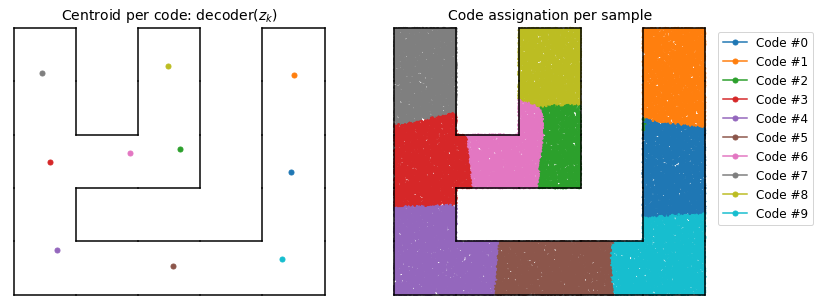

In [4]:
env, dataset = sample_dataset(config['maze_type'], num_samples=num_samples.value)

fig, axarr = plt.subplots(ncols=2, nrows=1, figsize=(12.5, 5))

ax = axarr[0]
env.maze.plot(ax)
color_mapping = []
for emb_idx in tqdm_notebook(range(vae.codebook_size)):
    s = vae.get_centroids(dict(skill=torch.tensor(emb_idx)))[0].detach().numpy()
    print(s)
    m = ax.plot(s[0], s[1], marker='o', markersize=5, label='Code #{}'.format(emb_idx))
    color_mapping.append(m[0].get_color())
color_mapping_rgb = [list(int(h.lstrip('#')[i:i+2], 16)/255. for i in (0, 2, 4)) for h in color_mapping]
legend = ax.legend(loc='upper right', bbox_to_anchor=(2.55, 1), fontsize=12, ncol=1)
config_subplot(ax, maze_type=config['maze_type'], title="Centroid per code: $\mathrm{decoder}(z_k)$")

ax = axarr[1]
env.maze.plot(ax)
z_q_x = vae.vq.quantize(vae.encoder(dataset)).detach().numpy()
plt.scatter(dataset[:, 0], dataset[:, 1], c=[color_mapping[z] for z in z_q_x], s=3, marker='o')
config_subplot(ax, maze_type=config['maze_type'], title="Code assignation per sample")

## 3. Configure and Run Zero-Shot Rollout

Based on the plot above, we define the parameters for our experiment. The `rollout_zero_shot` function will then generate trajectories for the interpolated skills and save them to the `zero_shot_logs` directory.

In [5]:
# --- Configuration ---
edl_exp_name = 'square_maze/edl_oracle' # The pre-trained agent we will use

# Choose two skills based on the plot above
skill_idx_1 = 7
skill_idx_2 = 4

# Number of intermediate points for interpolation (n=1 means one midpoint for a total of 3 skills)
num_interpolation = 3 

# Number of trajectories to generate for each skill
num_rollout_traj_each_mode = 5

# Directory to save the trajectory logs
base_save_dir = "logs_zero_shot"

# --- Execution ---
print("Loading pre-trained EDL agent: {}".format(edl_exp_name))
exp = Experiment(edl_exp_name)

rollout_interpolated_zero_shot(
    exp=exp,
    skill_idx_1=skill_idx_1,
    skill_idx_2=skill_idx_2,
    num_interpolation=num_interpolation,
    num_rollout_traj_each_mode=num_rollout_traj_each_mode,
    base_save_dir=base_save_dir
)

 26%|██▌       | 13/50 [00:00<00:00, 126.72it/s]

Loading pre-trained EDL agent: square_maze/edl_oracle


100%|██████████| 50/50 [00:00<00:00, 137.44it/s]


Saving zero-shot trajectories to: logs_zero_shot/square_maze/edl_oracle/zero_shot_of_7_4
Zero-shot rollouts completed and saved.


## 4. Visualize the Interpolated Trajectories

Finally, we load the logs we just generated and use `visualize_zero_shot` to plot the results. The plot should show smooth transitions in trajectories as the skill vector is interpolated from skill 1 to skill 2. The colors of the paths are also interpolated to match.

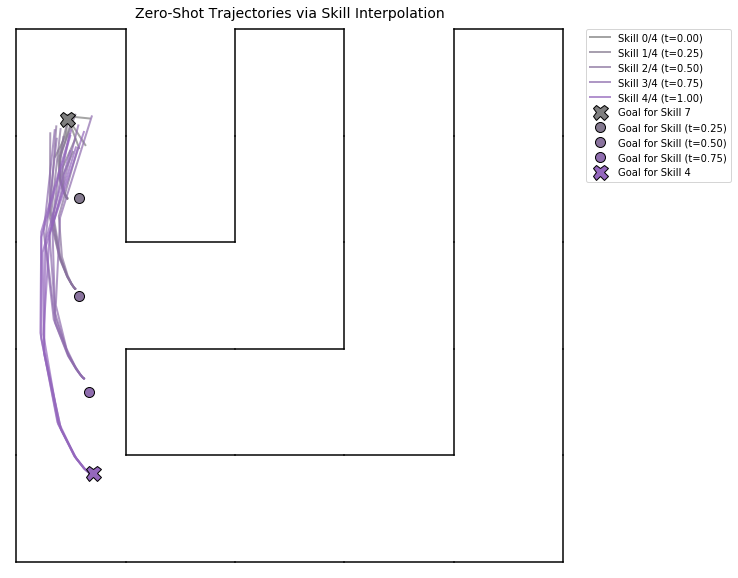

In [6]:
# --- Configuration ---
# This path must match the one constructed inside rollout_zero_shot
zero_shot_log_dir = os.path.join(base_save_dir, edl_exp_name, "zero_shot_of_{}_{}".format(skill_idx_1, skill_idx_2))

# --- Visualization ---
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

visualize_interpolated_zero_shot(
    zero_shot_log_path=zero_shot_log_dir,
    exp=exp,
    skill_idx_1=skill_idx_1,
    skill_idx_2=skill_idx_2,
    ax=ax,
    title="Zero-Shot Trajectories via Skill Interpolation"
)

plt.show()

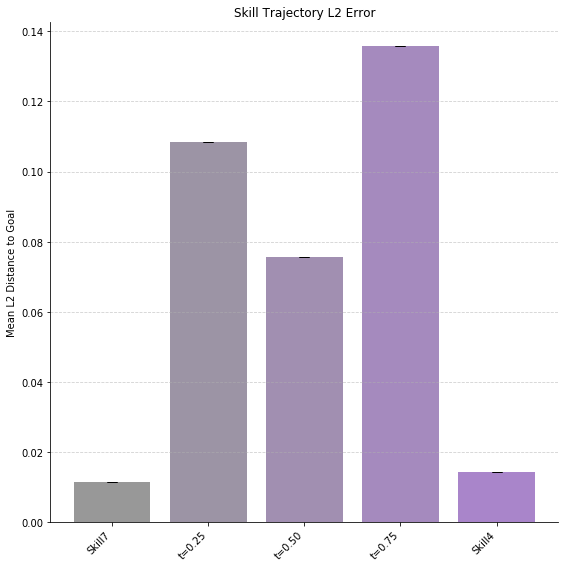

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
visualize_interpolated_traj_L2_error_bar_plot(
    zero_shot_log_dir,
    exp,
    skill_idx_1=skill_idx_1,
    skill_idx_2=skill_idx_2,
    ax=ax
)
plt.tight_layout()
plt.show()